# Classwork 09: Clustering Analysis (Breast Cancer Dataset)
Created by Golnaz Sahebi - Turku University of Applied Sciences - Spring 2026
<br> Organized by Gemini 3 Pro 

##  Assignment Overview
In this lab, you will step into the role of a data scientist working with medical diagnostic data. Unlike supervised learning where we tell the model the "answer" (Malignant vs. Benign), here we use **Unsupervised Learning** to see if the data naturally organizes itself into meaningful groups based on tumor characteristics.

### Your main mission is to:
You will implement and evaluate two distinct clustering approaches:
1. **K-Means (Partition-based):** You will search for the optimal number of "centroids" that represent tumor profiles.
   -  **Find the "Natural" Number of Clusters:** Use the **Elbow Method** and **Silhouette Analysis** to determine if the data points to two distinct groups or more.
2. **DBSCAN (Density-based):** You will attempt to find dense regions of similar cases while identifying outliers (noise) that don't fit the typical patterns.
   - **Handle High-Dimensional Density:** Use **DBSCAN** to identify dense regions of similar medical cases and isolate "noise" points that represent atypical or outlier tumor profiles.


---

##  Dataset: Breast Cancer Wisconsin (Diagnostic)
We are using a classic dataset containing features computed from digitized images of fine needle aspirates (FNA) of breast masses.

* **The Features:** You will work with 30 numeric attributes, such as **radius**, **texture**, **smoothness**, and **concavity**. 
* **Preprocessing Requirement:** In medical data, units vary wildly (e.g., area vs. smoothness). You **must** scale your data so that features with large numbers don't drown out the smaller, more subtle indicators.
*  **The Visualization Challenge:** The dataset we are using contains **30 different features** (measurements of cell nuclei). While clustering algorithms like **K-Means** and **DBSCAN** calculate distances using all 30 dimensions, humans can only visualize 2D or 3D space.

> **Important Instruction:** When generating scatter plots to "see" your clusters, you must select **only two features** (e.g., Feature 0 vs. Feature 1). Even though the algorithm is grouping points based on 30 variables, our "camera" can only look at two at a time.



---

## Your Workflow

### 1. Data Preparation
* Load the dataset and apply `StandardScaler`. Clustering algorithms rely on Euclidean distance, so scaling is non-negotiable.

### 2. K-Means Exploration
* Implement K-Means clustering by iterating through a range of $k$ values to partition the breast cancer data.
* Plot the Inertia (Sum of Squared Distances) for each $k$ to identify the "Elbow," which indicates where adding more clusters provides diminishing returns.
* Calculate the Silhouette Score for each $k$ to find the "peak" separation, helping you identify the most mathematically distinct number of clusters.


### 3. DBSCAN & Noise Detection
* Implement DBSCAN to find clusters based on density rather than centroids.
* Experiment with `eps` (Epsilon) and `min_samples`.
* **Goal:** Minimize noise points while maintaining distinct, meaningful clusters.

### 4. Evaluation
* Generate **Silhouette Diagrams**. A good cluster should have a silhouette coefficient well above the average and no "negative" samples (which indicate points assigned to the wrong group).


---

## Task 1: K-Means and the "Elbow" Method
The first step in K-Means is determining the optimal number of clusters ($k$).

1. **Initialize K-Means:** Run the K-Means algorithm for a range of $k$ values (e.g., $1$ to $10$).
2. **Plot the Elbow Curve:** Plot the Inertia against the number of clusters ($k$).
3. **Identify the Elbow:** Based on the plot, select the $k$ where the "arm" bends.
4. **Visualize:** Create a scatter plot using only two features (e.g., feature_1 on the x-axis and feature_2 on the y-axis). Color the points using the cluster labels generated by K-Means.


### Important Coding Note for Students
**Dimension Limitation:** When you use `plt.scatter()`, you can only provide two coordinates $(x, y)$.
- Incorrect: `plt.scatter(X, ...)` (This will fail because $X$ has 30 columns).
- Correct: `plt.scatter(X[:, 0], X[:, 1], c=labels)` (This uses only the first two columns of your data for the plot).

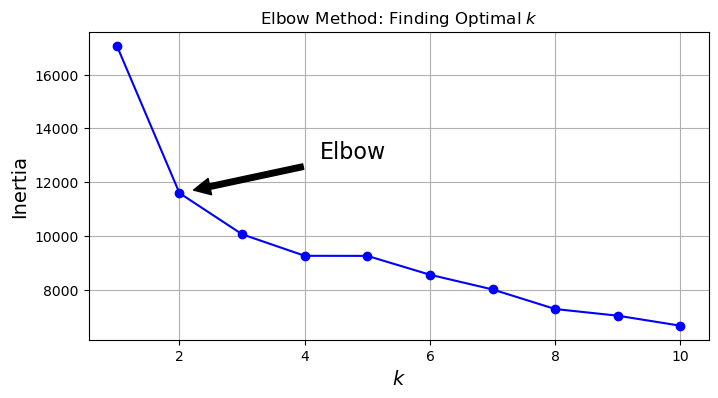

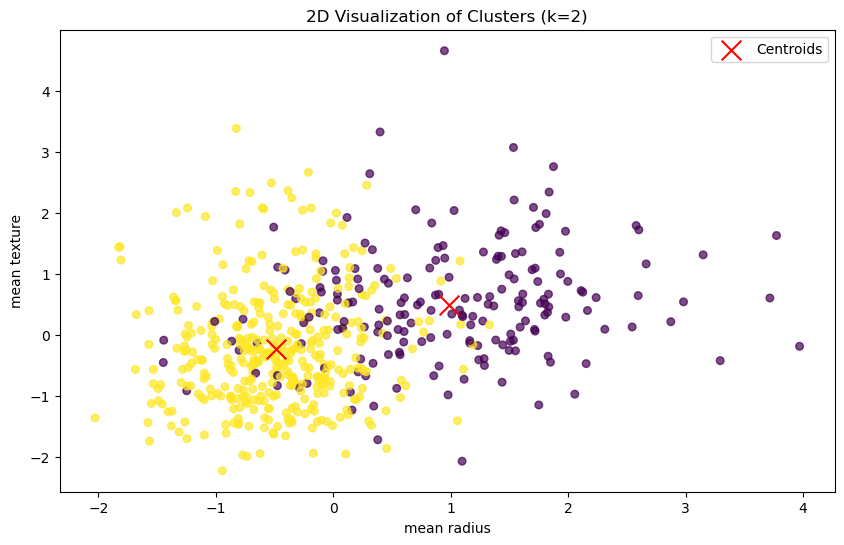

In [1]:
# Task 1: K-Means and the "Elbow" Method

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# 1. Load the Breast Cancer Dataset
cancer = load_breast_cancer()
X = cancer.data

# 2. Scale the data (Crucial for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Initialize K-Means and run for a range of k (1 to 10)
# We store the models in a list to reuse them later for Silhouette analysis
kmeans_per_k = [KMeans(n_clusters=k, random_state=42) for k in range(1, 11)]
inertias = [model.fit(X_scaled).inertia_ for model in kmeans_per_k]

# 4. Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Elbow Method: Finding Optimal $k$")
plt.grid(True)

# Annotate the "Elbow" (Usually k=2 for this dataset)
plt.annotate('Elbow',
             xy=(2, inertias[1]),
             xytext=(0.4, 0.6),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.show()

# 5. Visualize the Clusters using ONLY two features
# We will use Feature 0 (mean radius) and Feature 1 (mean texture)
# Note: We use the labels from the k=2 model (index 1 in our list)
k_optimal = 2
labels = kmeans_per_k[k_optimal - 1].labels_

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)

# Plot the Centroids (projected onto the same 2 features)
centroids = kmeans_per_k[k_optimal - 1].cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, c='red', label='Centroids')

plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title(f"2D Visualization of Clusters (k={k_optimal})")
plt.legend()
plt.show()


## Task 2: Silhouette Analysis (The "Knife" Plots)
1. **Generate Silhouette Diagrams:** For $k=2, 3, 4,$ and $5$, generate the silhouette diagrams (knife plots).
2. **Evaluate Quality:**
   * Do all "knives" cross the red dashed line (the average score)?
   * Are the clusters balanced in size (height of the knives)?
3. **Compare:** Does the Silhouette Analysis confirm the $k$ you chose during the Elbow Method?



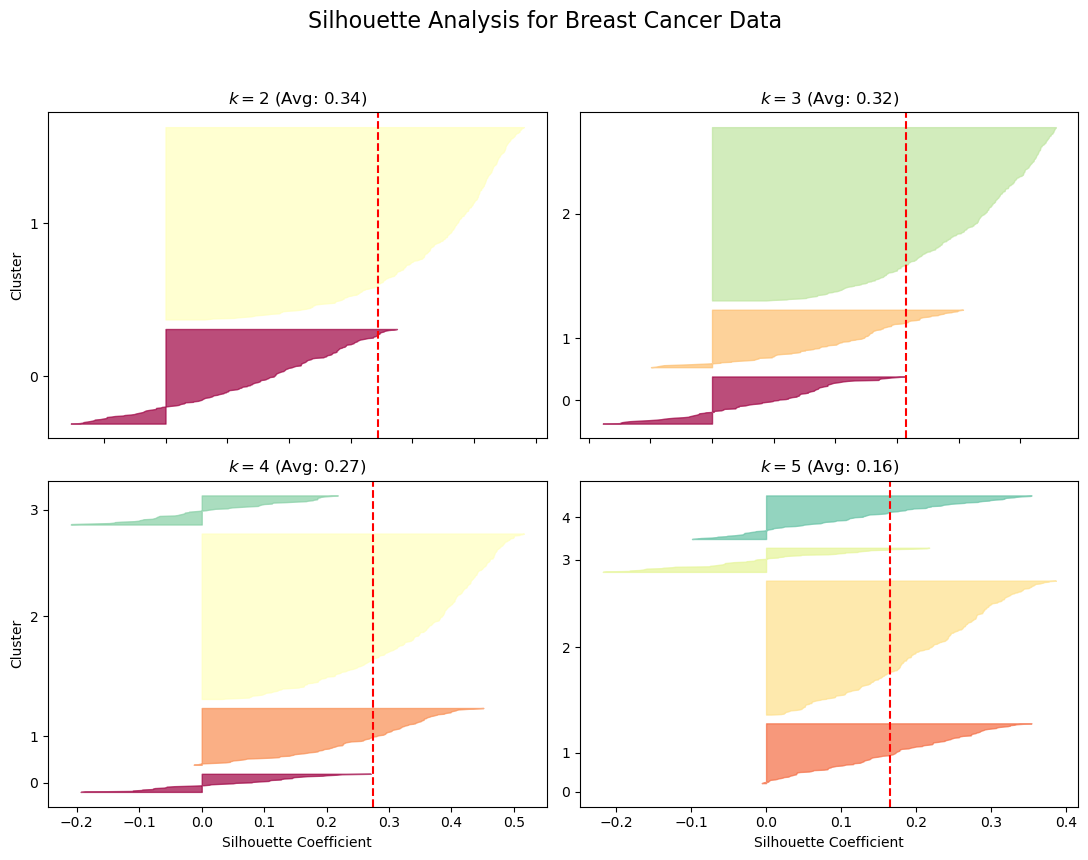

In [2]:
# Task 2: Silhouette Analysis (The "Knife" Plots)

from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import numpy as np

# 1. Calculate the Silhouette Scores for the red dashed lines
# Hint 1: We calculate silhouette scores for models starting from k=2 up to k=6.
# Hint 2: We slice [1:6] to skip the first model (k=1) because silhouette scores require at least two clusters to be calculated.
silhouette_scores = [silhouette_score(X_scaled, model.labels_) for model in kmeans_per_k[1:6]]

plt.figure(figsize=(11, 9))

# 2. Loop through k = 2, 3, 4, 5 to generate the "Knife" plots
for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    # Hint 3: Retrieve the model at index k-1 from our list and access its '.labels_' attribute to get the cluster assignments.
    # Hint 4: Use 'k-1' as the index to grab the model from kmeans_per_k that corresponds to the current number of clusters.
    y_pred = kmeans_per_k[k - 1].labels_
    
    # Hint 5: Use the silhouette_samples function with the scaled data (X_scaled) and the cluster labels you just assigned to y_pred.
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    
    if k in (2, 4):
        plt.ylabel("Cluster")
    
    if k in (4, 5):
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    # Draw the average score line
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$ (Avg: {silhouette_scores[k - 2]:.2f})")

plt.suptitle("Silhouette Analysis for Breast Cancer Data", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpreting the Silhouette Results (Breast Cancer Data)

After analyzing the Silhouette Diagrams (Knife Plots) for $k=2$ through $k=5$, we can draw the following conclusions:

#### 1. Do all "knives" cross the red dashed line?

Most knives do but not all cross the red dashed line. For k = 2 most are over the red line showing good clustering signs.

#### 2. Are the clusters balanced in size (height of the knives)?

No, they are not balanced in size, especially the bigger the k grows. But for k = 2, is more even and less fragmented.

#### 3. Does Silhouette Analysis confirm the Elbow Method?

It does, both Silhouette and Elbow method confirm that k = 2 is the most optimal clustering with avg of Silhouette score of 0.34.

---
## (Optional) Task 3: Density-Based Clustering (DBSCAN) Parameter Training & Evaluation

**Objective:** Train a DBSCAN model and evaluate its performance by identifying the number of clusters and noise points found.

**Instructions:**
1. **Train the Model:** Use the `DBSCAN` class from `sklearn.cluster`. Set `eps=0.5` and `min_samples=5` as a starting point.
2. **Fit the Data:** Use your scaled Breast Cancer data (`X_scaled`).
3. **Count the Results:**
   * How many **clusters** did the algorithm find? (Ignore the -1 label).
   * How many **noise points** (outliers) were identified? (Count the -1 labels).
4. Experiment: Change `eps` to a larger value (e.g., `3`) and a smaller value (e.g., `0.2`). Observe how the number of noise points changes.

**Note:** DBSCAN is a powerful alternative to K-Means because it doesn't force every point into a cluster. In a medical dataset like Breast Cancer, identifying **outliers** (noise) can be just as important as finding the clusters themselves.



In [7]:
# Task 3: Density-Based Clustering (DBSCAN)
# Note that DBSCAN is very sensitive to the eps parameter. Since we scaled our data in Task 1, 
# an eps between 0.5 and 3.0 is usually the "sweet spot" for this dataset.

from sklearn.cluster import DBSCAN
import numpy as np

# 1. Initialize and Fit DBSCAN
# We use eps=1.5 and min_samples=5 for a balanced result on scaled data
dbscan = DBSCAN(eps=2.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 2. Evaluate the results
# Hint 1: Use a set() to find all unique labels. The number of clusters is the 
# count of these unique labels, but don't forget to subtract 1 if '-1' (noise) is in the set!
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Hint 2: Convert the labels to a list and use the .count() method to find exactly how many points were assigned the value -1.
n_noise = list(labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# 3. Quick Peek at the labels
print(f"First 20 labels: {labels[:20]}")

Number of clusters found: 2
Number of noise points: 224
First 20 labels: [-1  0 -1 -1 -1 -1  0 -1 -1 -1  0  0 -1 -1 -1 -1  0 -1 -1  0]


### Task 3: Evaluating DBSCAN Results

#### 1. How many clusters were found?

DBSCAN produced different clustering results depending on the value of eps. So with eps 1 we founf 1 cluster and with eps 2.5 we found 2.

#### 2. What are the "Noise Points"?

Noise points are data points that are assigned the label -1 by the DBSCAN. These points could also not have enough neighboring points within the eps distance to be considered part of any cluster. So in this situation is the atypical cases that don't fit the standard patterns.

#### 3. Parameter Sensitivity (The 'Eps' Effect)
* **Small Eps (e.g., 0.2):** Most points will become noise (-1) because the "search radius" is too small to find neighbors.
* **Large Eps (e.g., 5.0):** Almost all points will be lumped into a single giant cluster (0) because the radius is so large it connects everything.
* **The Goal:** A "good" DBSCAN model finds the main clusters while isolating only the truly extreme outliers as noise.

---
##  Improving Your DBSCAN Results

Your current output may show a high number of **noise points (-1)** and only one cluster. This typically means the algorithm is being too "selective." To get better results, you’ll likely need to tune your hyperparameters:

---

### 1. Increase `eps` (Epsilon)
The `eps` parameter defines the maximum distance between two samples for one to be considered as in the neighborhood of the other.
* **The Problem:** Your `eps` is likely too small, so points can't "find" each other to form a cluster.
* **The Fix:** Gradually increase `eps`.
* **Pro Tip:** Use a **K-Distance Graph**. Plot the distance to the $k^{th}$ nearest neighbor for all points. The "elbow" of this graph is usually the sweet spot for your `eps` value.

### 2. Decrease `min_samples`
This parameter sets the minimum number of points required to form a "dense region" (a cluster).
* **The Problem:** If `min_samples` is too high, the algorithm won't start a cluster unless it finds a massive crowd of points.
* **The Fix:** Try lowering this value (the default is often 5). For 2D data, a common rule of thumb is `min_samples = 4`.

### 3. Scale Your Data
DBSCAN is extremely sensitive to the scale of your features because it relies on Euclidean distance.
* **The Problem:** If one feature ranges from 0 to 1 and another from 0 to 10,000, the distance calculation will be completely skewed.
* **The Fix:** Use `StandardScaler` or `MinMaxScaler` from `sklearn.preprocessing` before fitting the modelif you didn't.